In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohammadusamaqureshi/placement1/placement1.csv


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('/kaggle/input/datasets/mohammadusamaqureshi/placement1/placement1.csv')

In [9]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


/tmp/ipykernel_57/4191852838.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['iq'])


<Axes: xlabel='iq', ylabel='Density'>

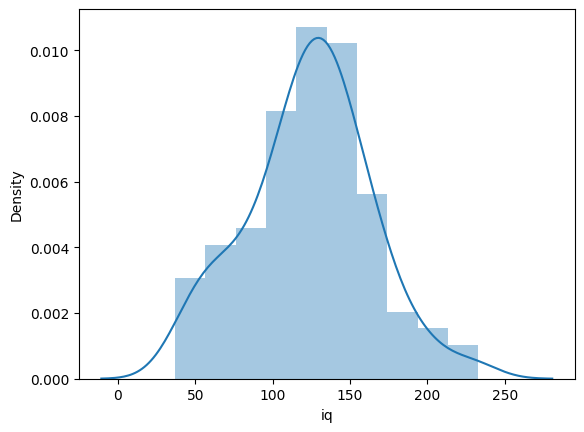

In [14]:
sns.distplot(df['iq'])

In [16]:
df['iq'].skew()

np.float64(0.018095580898964243)

In [17]:
df['cgpa'].skew()

np.float64(-0.0006954038546357086)

In [18]:
# The Column iq has not more skewed , but also we want to try on this

<Axes: ylabel='iq'>

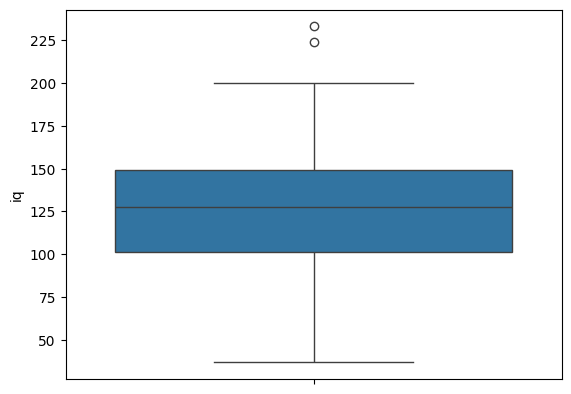

In [19]:
sns.boxplot(df['iq'])

In [23]:
q1=df['iq'].quantile(0.25)
q3=df['iq'].quantile(0.75)

In [24]:
IQR = q3-q1

In [25]:
maximum = q3+1.5*IQR
minimun = q1-1.5*IQR

In [27]:
df[df['iq']>maximum]

,Unnamed: 0,cgpa,iq,placement
16,16,5.2,224.0,0
50,50,3.5,233.0,0


In [29]:
df[df['iq']<minimun]

,Unnamed: 0,cgpa,iq,placement


In [30]:
df.shape

(100, 4)

In [31]:
new_df=df[df['iq']<maximum]

In [32]:
new_df.shape

(98, 4)

/tmp/ipykernel_57/946443382.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['iq'])
/tmp/ipykernel_57/946443382.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['iq'])


<Axes: ylabel='iq'>

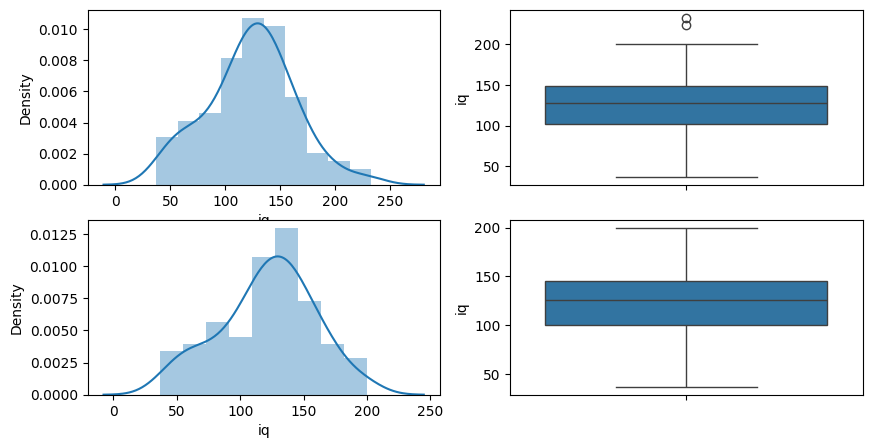

In [37]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
sns.distplot(df['iq'])

plt.subplot(2,2,2)
sns.boxplot(df['iq'])

plt.subplot(2,2,3)
sns.distplot(new_df['iq'])

plt.subplot(2,2,4)
sns.boxplot(new_df['iq'])

# Capping

In [38]:
new_df_cap = df.copy()

new_df_cap['iq']=np.where(
    new_df_cap['iq']>maximum,maximum,
    np.where(
        new_df_cap['iq']<minimun,minimun,
        new_df_cap['iq']
    )
)

<Axes: ylabel='iq'>

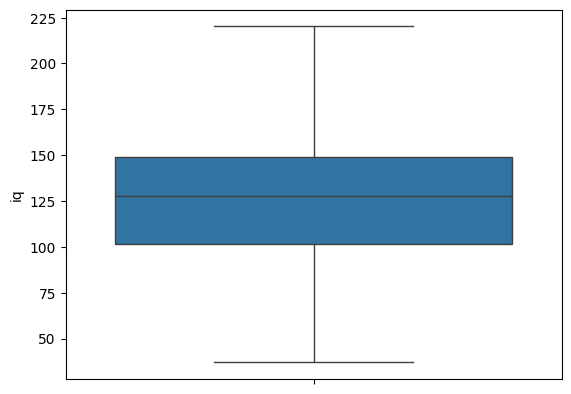

In [39]:
sns.boxplot(new_df_cap['iq'])

In [40]:
new_df_cap.shape

(100, 4)

/tmp/ipykernel_57/4140606769.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['iq'])
/tmp/ipykernel_57/4140606769.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['iq'])


<Axes: ylabel='iq'>

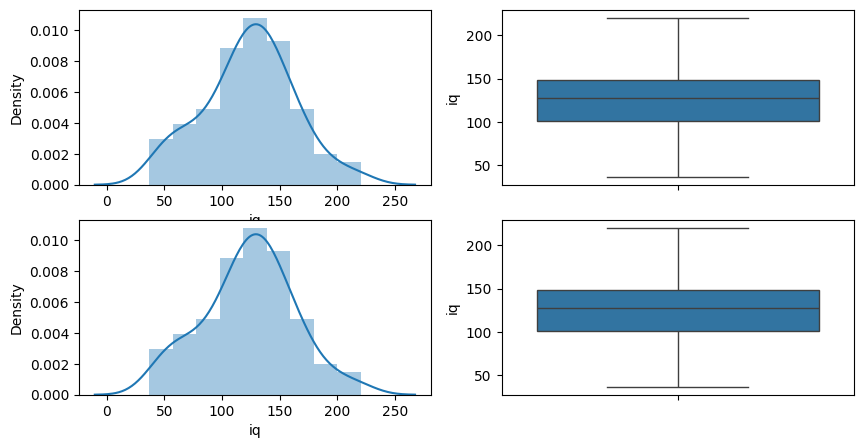

In [41]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
sns.distplot(new_df_cap['iq'])

plt.subplot(2,2,2)
sns.boxplot(new_df_cap['iq'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['iq'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['iq'])